In [1]:
%%capture
def running_in_colab():
    try:
        import google.colab  # type: ignore[import]  # noqa: F401
        return True
    except ImportError:
        return False

if running_in_colab():
    print("Colab detected → installing deps...")
    !pip install -q git+https://github.com/thatmariia/macro-eeg-model.git@erps


# Config

## Brain stuff

### Nodes (brain regions)

In [2]:
from macro_eeg.core import Node, NodesCollection

node_fl = Node(name="frontal lobe", code="FL")
node_pl = Node(name="parietal lobe", code="PL")
node_ol = Node(name="occiptal lobe", code="OL")
node_tl = Node(name="temporal lobe", code="TL")
node_t = Node(name="thalamus", code="T")
nodes = [node_fl, node_pl, node_ol, node_tl, node_t]

nodes_collection = NodesCollection(nodes=nodes)

### Edges

In [3]:
from macro_eeg.core import Edge, EdgesCollection

edge_fl_pl, edge_pl_fl  = Edge(src=node_fl, dst=node_pl).with_reversed()
edge_fl_ol, edge_ol_fl  = Edge(src=node_fl, dst=node_ol).with_reversed()
edge_fl_tl, edge_tl_fl  = Edge(src=node_fl, dst=node_tl).with_reversed()
edge_fl_t, edge_t_fl    = Edge(src=node_fl, dst=node_t).with_reversed()
edge_pl_ol, edge_ol_pl  = Edge(src=node_pl, dst=node_ol).with_reversed()
edge_pl_tl, edge_tl_pl  = Edge(src=node_pl, dst=node_tl).with_reversed()
edge_pl_t, edge_t_pl    = Edge(src=node_pl, dst=node_t).with_reversed()
edge_ol_tl, edge_tl_ol  = Edge(src=node_ol, dst=node_tl).with_reversed()
edge_ol_t, edge_t_ol    = Edge(src=node_ol, dst=node_t).with_reversed()
edge_tl_t, edge_t_tl    = Edge(src=node_tl, dst=node_t).with_reversed()

### Distances

In [4]:
from macro_eeg.core import EdgeDistance

dist_fl_pl, dist_pl_fl  = EdgeDistance(edge=edge_fl_pl, distance=87.694797).with_reversed()
dist_fl_ol, dist_ol_fl  = EdgeDistance(edge=edge_fl_ol, distance=79.780942).with_reversed()
dist_fl_tl, dist_tl_fl  = EdgeDistance(edge=edge_fl_tl, distance=59.550866).with_reversed()
dist_fl_t, dist_t_fl    = EdgeDistance(edge=edge_fl_t,  distance=50.410222).with_reversed()
dist_pl_ol, dist_ol_pl  = EdgeDistance(edge=edge_pl_ol, distance=85.579993).with_reversed()
dist_pl_tl, dist_tl_pl  = EdgeDistance(edge=edge_pl_tl, distance=73.568051).with_reversed()
dist_pl_t, dist_t_pl    = EdgeDistance(edge=edge_pl_t,  distance=75.444747).with_reversed()
dist_ol_tl, dist_tl_ol  = EdgeDistance(edge=edge_ol_tl, distance=89.062507).with_reversed()
dist_ol_t, dist_t_ol    = EdgeDistance(edge=edge_ol_t,  distance=94.531546).with_reversed()
dist_tl_t, dist_t_tl    = EdgeDistance(edge=edge_tl_t,  distance=65.734991).with_reversed()
distances = [
    dist_fl_pl, dist_pl_fl,
    dist_fl_ol, dist_ol_fl,
    dist_fl_tl, dist_tl_fl,
    dist_fl_t, dist_t_fl,
    dist_pl_ol, dist_ol_pl,
    dist_pl_tl, dist_tl_pl,
    dist_pl_t, dist_t_pl,
    dist_ol_tl, dist_tl_ol,
    dist_ol_t, dist_t_ol,
    dist_tl_t, dist_t_tl
]

distances_collection = EdgesCollection.from_edges(distances, nodes_collection=nodes_collection)

### Baseline connectivity

In [5]:
from macro_eeg.core import EdgeConnectivity

cw_fl_pl, cw_pl_fl  = EdgeConnectivity(edge=edge_fl_pl, weight=0.80).with_reversed()
cw_fl_ol, cw_ol_fl  = EdgeConnectivity(edge=edge_fl_ol, weight=0.80).with_reversed()
cw_fl_tl, cw_tl_fl  = EdgeConnectivity(edge=edge_fl_tl, weight=0.30).with_reversed()
cw_fl_t, cw_t_fl    = EdgeConnectivity(edge=edge_fl_t,  weight=0.10).with_reversed()
cw_pl_ol, cw_ol_pl  = EdgeConnectivity(edge=edge_pl_ol, weight=1.20).with_reversed()
cw_pl_tl, cw_tl_pl  = EdgeConnectivity(edge=edge_pl_tl, weight=0.75).with_reversed()
cw_pl_t, cw_t_pl    = EdgeConnectivity(edge=edge_pl_t,  weight=0.10).with_reversed()
cw_ol_tl, cw_tl_ol  = EdgeConnectivity(edge=edge_ol_tl, weight=0.80).with_reversed()
cw_ol_t, cw_t_ol    = EdgeConnectivity(edge=edge_ol_t,  weight=0.10).with_reversed()
cw_tl_t, cw_t_tl    = EdgeConnectivity(edge=edge_tl_t,  weight=0.10).with_reversed()
connectivity = [
    cw_fl_pl, cw_pl_fl,
    cw_fl_ol, cw_ol_fl,
    cw_fl_tl, cw_tl_fl,
    cw_fl_t, cw_t_fl,
    cw_pl_ol, cw_ol_pl,
    cw_pl_tl, cw_tl_pl,
    cw_pl_t, cw_t_pl,
    cw_ol_tl, cw_tl_ol,
    cw_ol_t, cw_t_ol,
    cw_tl_t, cw_t_tl
]

connectivity_collection = EdgesCollection.from_edges(connectivity, nodes_collection=nodes_collection)

### Axon diameter distribution & delay pdf

In [6]:
from macro_eeg.core import DiameterDist

diameter_dist = DiameterDist(
    shape=-0.25,
    scale=0.09,
    location=0.25,
)

In [7]:
from macro_eeg.utils import get_delay_pdf_fn

delay_pdf_fn = get_delay_pdf_fn(diameter_dist)

## Stimuli with functions & connectivity

In [8]:
import math

def intensity(high: list[float], low: list[float]) -> float:
    # check not both empty
    if not high and not low:
        raise ValueError("Both high and low frequency lists are empty")
    high_weight = 0.7
    low_weight = 0.3
    high_multiplied = math.prod(high) if high else 0.0
    low_multiplied = math.prod(low) if low else 0.0
    return high_weight * high_multiplied + low_weight * low_multiplied

n1 = 0.6
n0 = 0.8
p0 = 1.2
p1 = 1.5
p2 = 2.0
p3 = 3.0
p4 = 5.0

In [9]:
from macro_eeg.core import Stimulus, StimulusNodeTarget, EdgeConnectivityCoef
from macro_eeg.utils import get_stimulus_fn, get_time_fn

### Pre-ERP

In [10]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_t_ol, coef=intensity([p3], [])),
    EdgeConnectivityCoef(edge=edge_fl_ol, coef=intensity([], [n0])),
    EdgeConnectivityCoef(edge=edge_pl_ol, coef=intensity([], [n0])),
]
edge_coeffs_collection = EdgesCollection.from_edges(
    edge_coeffs, nodes_collection=nodes_collection, default_value=1.0
)

stimulus0 = Stimulus(
    name="pre-erp",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.2),
        StimulusNodeTarget(node=node_pl, coef=0.5),
        StimulusNodeTarget(node=node_ol, coef=1.0),
        StimulusNodeTarget(node=node_tl, coef=0.7),
        StimulusNodeTarget(node=node_t, coef=0.6),
    ],
    onset_ms=get_time_fn(time=(20, 25), strategy="random"),
    duration_ms=get_time_fn(time=(40, 55), strategy="random"),
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=0.0, strategy="step"),
)


### P1

In [11]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_ol_tl, coef=intensity([], [n0])),
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=intensity([], [n0])),
    EdgeConnectivityCoef(edge=edge_pl_fl, coef=intensity([], [n1, n1])),
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=intensity([], [n1])),
]
edge_coeffs_collection = EdgesCollection.from_edges(
    edge_coeffs, nodes_collection=nodes_collection, default_value=1.0
)

stimulus1 = Stimulus(
    name="p100",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.2),
        StimulusNodeTarget(node=node_pl, coef=0.5),
        StimulusNodeTarget(node=node_ol, coef=1.0),
        StimulusNodeTarget(node=node_tl, coef=0.7),
        StimulusNodeTarget(node=node_t, coef=0.6),
    ],
    onset_ms=get_time_fn(time=(60, 80), strategy="random"),
    duration_ms=get_time_fn(time=(60, 80), strategy="random"),
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=5.0, strategy="step"),
)

### N2

In [12]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_ol_tl, coef=intensity([p2], [])),
    EdgeConnectivityCoef(edge=edge_tl_pl, coef=intensity([p3], [])),
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=intensity([p3], [])),
    EdgeConnectivityCoef(edge=edge_pl_fl, coef=intensity([p3], [n0])),
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=intensity([p1], [n0])),
]
edge_coeffs_collection = EdgesCollection.from_edges(
    edge_coeffs, nodes_collection=nodes_collection, default_value=1.0
)

stimulus2 = Stimulus(
    name="n200",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=1.00),
        StimulusNodeTarget(node=node_pl, coef=0.80),
        StimulusNodeTarget(node=node_ol, coef=0.70),
        StimulusNodeTarget(node=node_tl, coef=0.70),
        StimulusNodeTarget(node=node_t, coef=0.40),
    ],
    onset_ms=get_time_fn(time=(170, 220), strategy="random"),
    duration_ms=get_time_fn(time=(120, 180), strategy="random"),
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=-4.0, strategy="step"),
)

### P3

In [13]:
edge_coeffs = [
    EdgeConnectivityCoef(edge=edge_pl_fl, coef=intensity([p3, p0], [n0])),
    EdgeConnectivityCoef(edge=edge_fl_pl, coef=intensity([p4], [n1])),
    EdgeConnectivityCoef(edge=edge_ol_tl, coef=intensity([], [n0])),
    EdgeConnectivityCoef(edge=edge_ol_pl, coef=intensity([], [n0])),
]
edge_coeffs_collection = EdgesCollection.from_edges(
    edge_coeffs, nodes_collection=nodes_collection, default_value=1.0
)

stimulus3 = Stimulus(
    name="p300",
    node_targets=[
        StimulusNodeTarget(node=node_fl, coef=0.70),
        StimulusNodeTarget(node=node_pl, coef=1.00),
        StimulusNodeTarget(node=node_ol, coef=0.60),
        StimulusNodeTarget(node=node_tl, coef=0.80),
        StimulusNodeTarget(node=node_t, coef=0.70),
    ],
    onset_ms=get_time_fn(time=(260, 320), strategy="random"),
    duration_ms=get_time_fn(time=(240, 320), strategy="random"),
    edge_coeffs=edge_coeffs_collection,
    stimulus_fn=get_stimulus_fn(amplitude=7.0, strategy="step"),
)

In [14]:
stimuli = [stimulus0, stimulus1, stimulus2, stimulus3]

## Stimuli with functions

### Pre-ERP

In [15]:
stimulus0_functions = Stimulus(
    name=stimulus0.name,
    node_targets=stimulus0.node_targets,
    onset_ms=stimulus0.onset_ms,
    duration_ms=stimulus0.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus0.stimulus_fn,
)

### P1

In [16]:
stimulus1_functions = Stimulus(
    name=stimulus1.name,
    node_targets=stimulus1.node_targets,
    onset_ms=stimulus1.onset_ms,
    duration_ms=stimulus1.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus1.stimulus_fn,
)

### N2

In [17]:
stimulus2_functions = Stimulus(
    name=stimulus2.name,
    node_targets=stimulus2.node_targets,
    onset_ms=stimulus2.onset_ms,
    duration_ms=stimulus2.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus2.stimulus_fn,
)

### P3

In [18]:
stimulus3_functions = Stimulus(
    name=stimulus3.name,
    node_targets=stimulus3.node_targets,
    onset_ms=stimulus3.onset_ms,
    duration_ms=stimulus3.duration_ms,
    edge_coeffs=None,
    stimulus_fn=stimulus3.stimulus_fn,
)

In [19]:
stimuli_functions = [
    stimulus0_functions,
    stimulus1_functions,
    stimulus2_functions,
    stimulus3_functions,
]

## Stimuli with connectivity

### Pre-ERP

In [20]:
stimulus0_connectivity = Stimulus(
    name=stimulus0.name,
    node_targets=stimulus0.node_targets,
    onset_ms=stimulus0.onset_ms,
    duration_ms=stimulus0.duration_ms,
    edge_coeffs=stimulus0.edge_coeffs,
    stimulus_fn=None,
)

### P1

In [21]:
stimulus1_connectivity = Stimulus(
    name=stimulus1.name,
    node_targets=stimulus1.node_targets,
    onset_ms=stimulus1.onset_ms,
    duration_ms=stimulus1.duration_ms,
    edge_coeffs=stimulus1.edge_coeffs,
    stimulus_fn=None,
)

### N2

In [22]:
stimulus2_connectivity = Stimulus(
    name=stimulus2.name,
    node_targets=stimulus2.node_targets,
    onset_ms=stimulus2.onset_ms,
    duration_ms=stimulus2.duration_ms,
    edge_coeffs=stimulus2.edge_coeffs,
    stimulus_fn=None,
)

### P3

In [23]:
stimulus3_connectivity = Stimulus(
    name=stimulus3.name,
    node_targets=stimulus3.node_targets,
    onset_ms=stimulus3.onset_ms,
    duration_ms=stimulus3.duration_ms,
    edge_coeffs=stimulus3.edge_coeffs,
    stimulus_fn=None,
)

In [24]:
stimuli_connectivity = [
    stimulus0_connectivity,
    stimulus1_connectivity,
    stimulus2_connectivity,
    stimulus3_connectivity,
]

## Simulation params & noise

In [25]:
from macro_eeg.core import SimulationParams

sim_params = SimulationParams(
    sample_rate_hz=1000,
    lags_ms=300,
    sim_ms=1000,
    burnin_ms=100
)

In [26]:
from macro_eeg.utils import get_noise_fn

noise_fn = get_noise_fn(
    std=2.0,
    strategy="white"
)

# Simulation

In [27]:
import matplotlib.pyplot as plt

## Weighted lag distribution effects

In [28]:
from macro_eeg.simulation import compute_lag_effects

lag_base, lags_stim = compute_lag_effects(
    base_connectivity=connectivity_collection,
    distances=distances_collection,
    delay_pdf_fn=delay_pdf_fn,
    sim_params=sim_params,
    stimuli=stimuli,
    make_base_stationary=True,
    make_stim_stationary=False,
    shrink=0.5,
    show_progress=True,
)

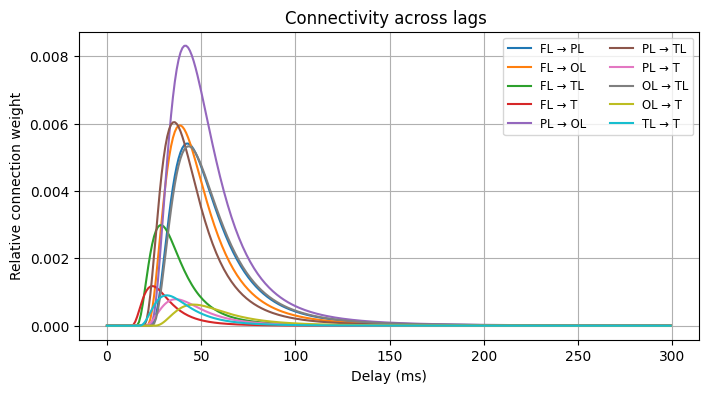

In [29]:
from macro_eeg.viz import plot_lag_connectivity

fig, ax = plt.subplots(figsize=(8, 4))

fig, ax = plot_lag_connectivity(
    lag_connectivity=lag_base,
    node_names=[node.code for node in nodes_collection.nodes],
    plot_name=None,
    ax=ax
)

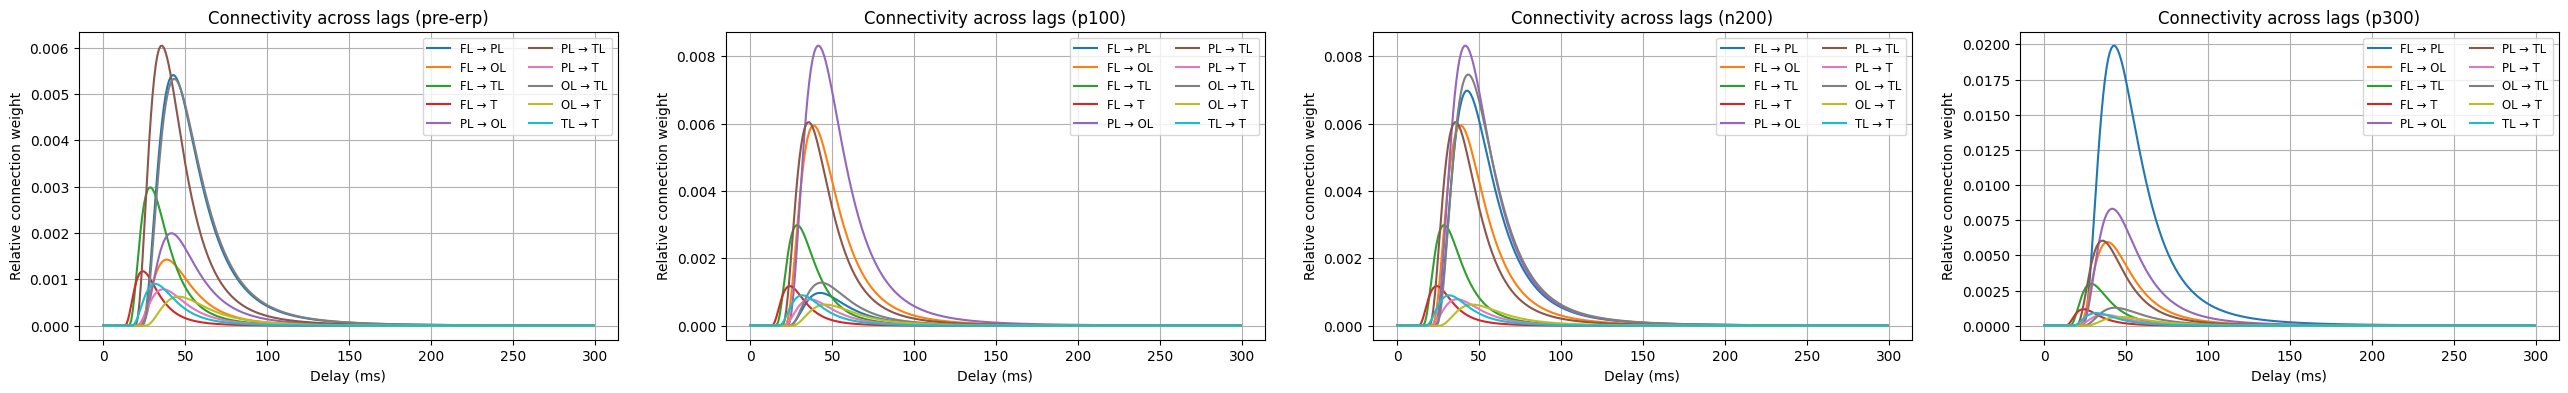

In [30]:
if lags_stim:
    fig, axes = plt.subplots(1, len(lags_stim), figsize=(8 * len(lags_stim), 4))
    axes = axes.ravel()

    for i, ax in enumerate(axes):
        plot_lag_connectivity(
            lag_connectivity=lags_stim[i],
            node_names=[node.code for node in nodes_collection.nodes],
            plot_name=stimuli[i].name,
            ax=ax
        )

## VAR simulation

In [31]:
%%capture
from macro_eeg.simulation import simulate_and_power
from macro_eeg.viz import plot_simulation, plot_power
import numpy as np

nr_trials = 10
cooldown = 10
smooth = 1000 #10000.0

In [32]:
def local_simulate_and_power(
    lags_stim,
    stimuli,
):
    return simulate_and_power(
        noise_fn=noise_fn,
        nodes=nodes_collection,
        params=sim_params,
        lag_base=lag_base,
        lags_stim=lags_stim,
        stimuli=stimuli,
        nr_trials=nr_trials,
        pass_freq=1,
        stop_freq=0.25,
        show_progress=True,
        parallel_trials=2,
        cooldown=cooldown,
    )


index_to_lbl={i: node.code for i, node in nodes_collection.index_to_node.items()}

def _plot_data(data, ax, smoothing=None, plot_name=None):
    if data is None:
        return ax
    _, ax = plot_simulation(
        data=data,
        sample_rate=sim_params.sample_rate_hz,
        index_to_lbl=index_to_lbl,
        stim_windows=None,
        smooth=smoothing,
        plot_name=plot_name,
        ax=ax,
    )
    return ax

def _plot_power_data(power_data, ax):
    freqs, power = power_data
    _, ax = plot_power(
        freqs=freqs,
        power=power,
        index_to_lbl=index_to_lbl,
        ax=ax,
    )
    return ax

def plot_all_data(data, stim_data, power_data, plot_name=None):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8 * 3, 4))
    ax[0] = _plot_data(
        data=data,
        ax=ax[0],
        smoothing=smooth,
        plot_name=plot_name,
    )
    ax[1] = _plot_data(
        data=stim_data,
        ax=ax[1],
    )
    ax[2] = _plot_power_data(
        power_data=power_data,
        ax=ax[2],
    )
    return fig, ax

### No stimuli

In [33]:
data, stim_data, power = local_simulate_and_power(
    lags_stim=None,
    stimuli=None,
)

Simulating (all trials):   0%|          | 0/11000 [00:00<?, ?step/s]trial 0 pid=58660 ...
trial 1 pid=58661 ...
trial 2 pid=58660 ...
trial 3 pid=58661 ...
Simulating (all trials):   2%|▏         | 200/11000 [00:01<01:12, 149.37step/s]trial 4 pid=58660 ...
trial 5 pid=58661 ...
Simulating (all trials):  42%|████▏     | 4600/11000 [00:01<00:42, 149.37step/s, last=T4, done_trials=4]trial 6 pid=58661 ...
trial 7 pid=58660 ...
trial 8 pid=58661 ...
trial 9 pid=58660 ...
Simulating (all trials): 100%|██████████| 11000/11000 [00:01<00:00, 6929.40step/s, last=T8, done_trials=8]


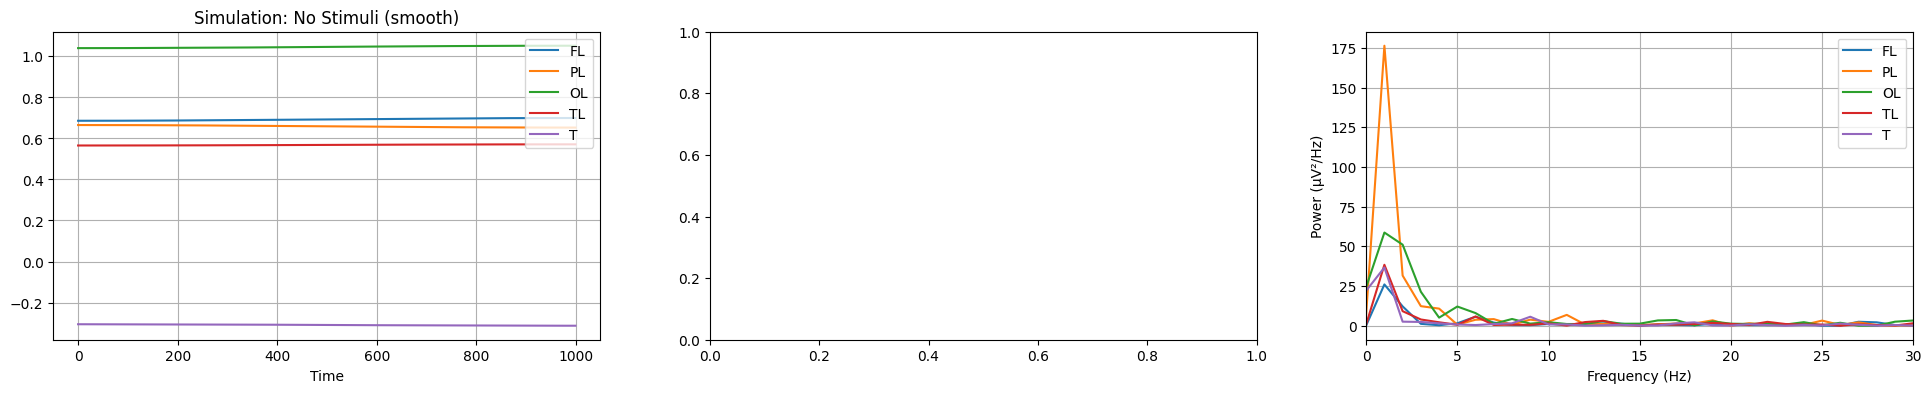

In [34]:
plot_all_data(
    data=data,
    stim_data=stim_data,
    power_data=power,
    plot_name="No Stimuli",
);

### Stimuli with functions & connectivity

In [35]:
data, stim_data, power = local_simulate_and_power(
    lags_stim=lags_stim,
    stimuli=stimuli,
)

DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 41
DEBUG: resolved stimulus 'p100' onset_ms: 63, duration_ms: 62
DEBUG: resolved stimulus 'n200' onset_ms: 213, duration_ms: 152
DEBUG: resolved stimulus 'p300' onset_ms: 319, duration_ms: 309
DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 52
DEBUG: resolved stimulus 'p100' onset_ms: 64, duration_ms: 65
DEBUG: resolved stimulus 'n200' onset_ms: 203, duration_ms: 161
DEBUG: resolved stimulus 'p300' onset_ms: 280, duration_ms: 282
DEBUG: resolved stimulus 'pre-erp' onset_ms: 20, duration_ms: 45
DEBUG: resolved stimulus 'p100' onset_ms: 63, duration_ms: 66
DEBUG: resolved stimulus 'n200' onset_ms: 175, duration_ms: 135
DEBUG: resolved stimulus 'p300' onset_ms: 273, duration_ms: 303
DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 42
DEBUG: resolved stimulus 'p100' onset_ms: 62, duration_ms: 74
DEBUG: resolved stimulus 'n200' onset_ms: 206, duration_ms: 121
DEBUG: resolved stimulus 'p300' onset_ms: 31

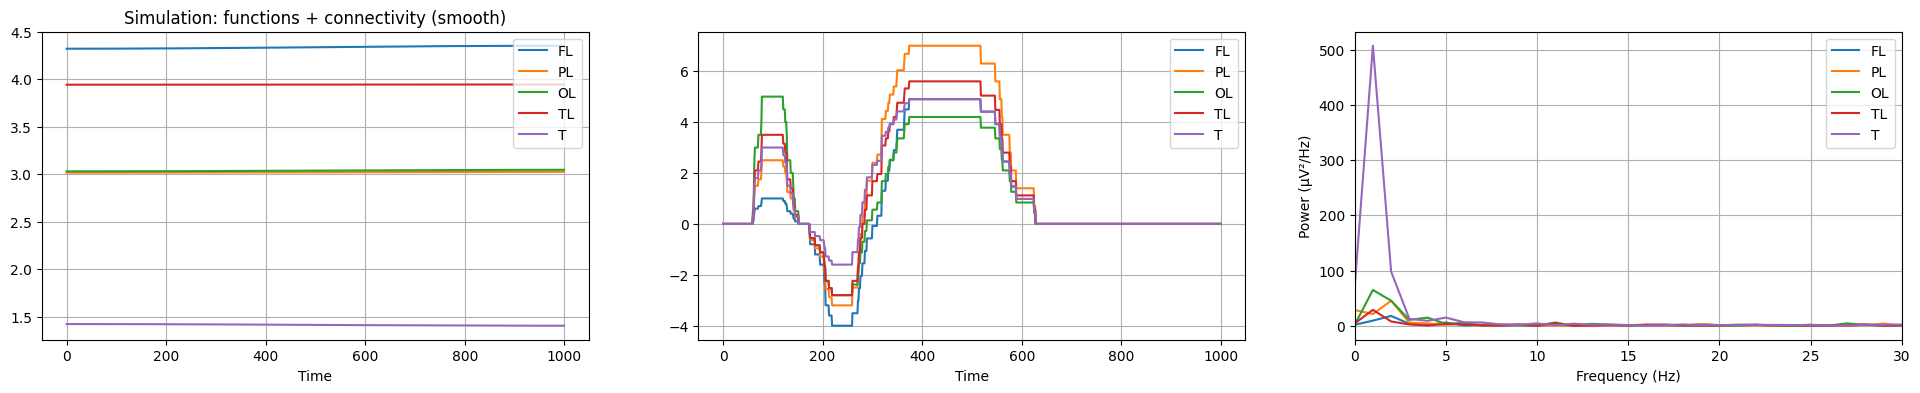

In [36]:
plot_all_data(
    data=data,
    stim_data=stim_data,
    power_data=power,
    plot_name="functions + connectivity",
);

### Stimuli with functions

In [37]:
data, stim_data, power = local_simulate_and_power(
    lags_stim=None,
    stimuli=stimuli_functions,
)

DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 48
DEBUG: resolved stimulus 'p100' onset_ms: 72, duration_ms: 74
DEBUG: resolved stimulus 'n200' onset_ms: 208, duration_ms: 141
DEBUG: resolved stimulus 'p300' onset_ms: 294, duration_ms: 268
DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 53
DEBUG: resolved stimulus 'p100' onset_ms: 75, duration_ms: 64
DEBUG: resolved stimulus 'n200' onset_ms: 201, duration_ms: 133
DEBUG: resolved stimulus 'p300' onset_ms: 290, duration_ms: 293
DEBUG: resolved stimulus 'pre-erp' onset_ms: 21, duration_ms: 49
DEBUG: resolved stimulus 'p100' onset_ms: 70, duration_ms: 67
DEBUG: resolved stimulus 'n200' onset_ms: 174, duration_ms: 152
DEBUG: resolved stimulus 'p300' onset_ms: 276, duration_ms: 284
DEBUG: resolved stimulus 'pre-erp' onset_ms: 22, duration_ms: 50
DEBUG: resolved stimulus 'p100' onset_ms: 64, duration_ms: 62
DEBUG: resolved stimulus 'n200' onset_ms: 211, duration_ms: 172
DEBUG: resolved stimulus 'p300' onset_ms: 28

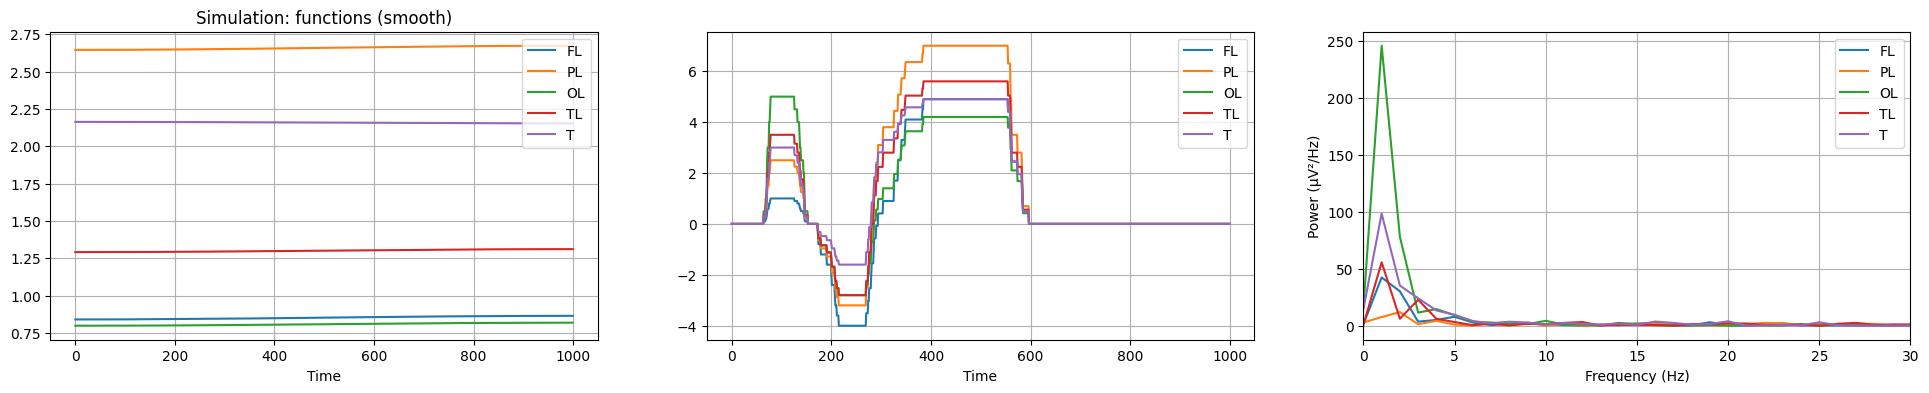

In [38]:
plot_all_data(
    data=data,
    stim_data=stim_data,
    power_data=power,
    plot_name="functions",
);

### Stimuli with connectivity

In [39]:
data, stim_data, power = local_simulate_and_power(
    lags_stim=lags_stim,
    stimuli=stimuli_connectivity,
)

DEBUG: resolved stimulus 'pre-erp' onset_ms: 22, duration_ms: 53
DEBUG: resolved stimulus 'p100' onset_ms: 62, duration_ms: 72
DEBUG: resolved stimulus 'n200' onset_ms: 173, duration_ms: 174
DEBUG: resolved stimulus 'p300' onset_ms: 319, duration_ms: 295
DEBUG: resolved stimulus 'pre-erp' onset_ms: 24, duration_ms: 43
DEBUG: resolved stimulus 'p100' onset_ms: 65, duration_ms: 77
DEBUG: resolved stimulus 'n200' onset_ms: 179, duration_ms: 144
DEBUG: resolved stimulus 'p300' onset_ms: 309, duration_ms: 255
DEBUG: resolved stimulus 'pre-erp' onset_ms: 22, duration_ms: 47
DEBUG: resolved stimulus 'p100' onset_ms: 73, duration_ms: 75
DEBUG: resolved stimulus 'n200' onset_ms: 212, duration_ms: 149
DEBUG: resolved stimulus 'p300' onset_ms: 314, duration_ms: 254
DEBUG: resolved stimulus 'pre-erp' onset_ms: 20, duration_ms: 43
DEBUG: resolved stimulus 'p100' onset_ms: 61, duration_ms: 75
DEBUG: resolved stimulus 'n200' onset_ms: 216, duration_ms: 148
DEBUG: resolved stimulus 'p300' onset_ms: 29

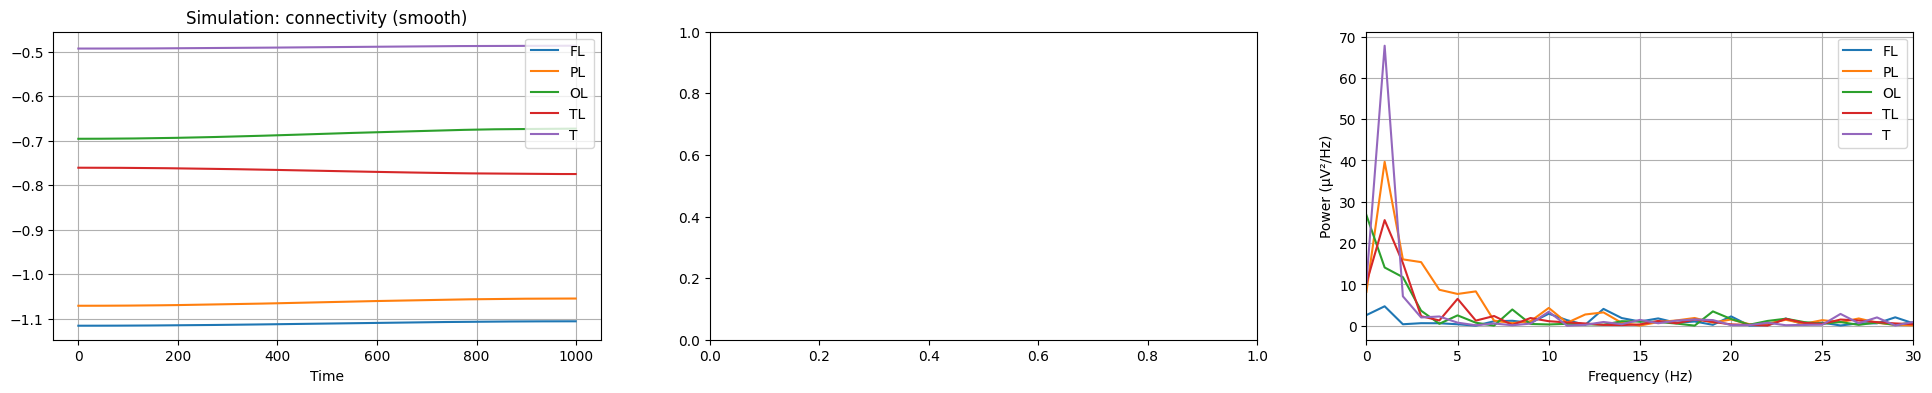

In [40]:
plot_all_data(
    data=data,
    stim_data=stim_data,
    power_data=power,
    plot_name="connectivity",
);